In [56]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print(np.__version__)

1.26.4


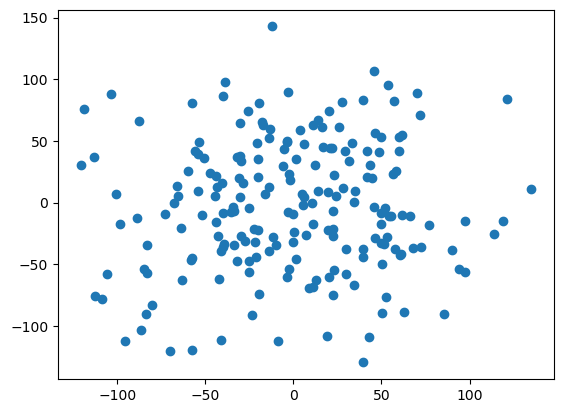

In [2]:
from utils import create_dopant_configuration

R = 150
n_a = 200
save_dir = "/home/hd/hd_hd/hd_gy283/kmc_project/configs"
_ = create_dopant_configuration(radius=R, n_a=n_a, n_d=3, name_a="robustness_acc", name_d="robustness_don", mode="mixed", eps=0.8, save_dir=save_dir)

acc_pos = np.loadtxt(f"{save_dir}/robustness_acc.txt")
plt.scatter(*acc_pos.T)

[ 98 178  50  91  49 124  43  30 114  24 101  20  97 174  92 191 155  63
 103   3]
(200, 2)
(200, 2)


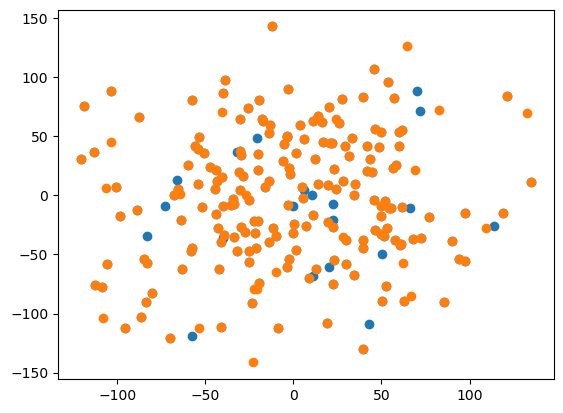

In [54]:
acc_pos = np.loadtxt(f"/home/hd/hd_hd/hd_gy283/kmc_project/configs/robustness_to_acc/robustness_acc.txt")

n_rand = 20

new_pos = acc_pos.copy()

acc_indices = np.random.choice(n_a, size=n_rand, replace=False)
print(acc_indices)

for idx in acc_indices:
    radius = R * np.sqrt(np.random.uniform(0.0, 1.0))
    phi = np.random.uniform(0.0, 2*np.pi)
    x = radius*np.cos(phi)
    y = radius*np.sin(phi)

    new_pos[idx] = np.array([x, y])
print(new_pos.shape)
print(acc_pos.shape)
plt.scatter(*acc_pos.T)
plt.scatter(*new_pos.T)

np.savetxt(f"{save_dir}/robustness_acc_nrand={n_rand}.txt", new_pos, fmt="%.6f", delimiter="\t")

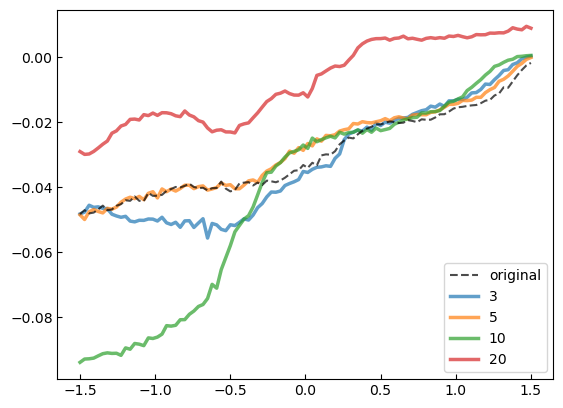

In [92]:
ROOT = Path("/home/hd/hd_hd/hd_gy283/kmc_project")
WS_DIR = Path("/gpfs/bwfor/work/ws/hd_gy283-my_data")
BINARY = ROOT / "build" / "kmc_project"
SH_SCRIPT = ROOT / "scripts" / "slurm" / "single_curve.sh"

nrands = [3, 5, 10, 20]

unchanged_pos = np.load(f"{WS_DIR}/robustness_acceptor_changes/acc_unchanged.npz")
x = np.linspace(-1.5, 1.5, 100)
plt.plot(x, unchanged_pos["current"], alpha=.7, lw=1.5, c="k", linestyle="dashed", label="original", zorder=3)
for i in nrands:
    changed_pos = np.load(f"{WS_DIR}/robustness_acceptor_changes/acc_changed_nrand={i}.npz")
    plt.plot(x, changed_pos["current"], alpha=.7, label=f"{i}", lw=2.5)
    plt.tick_params(which="major", direction="in")

plt.legend()

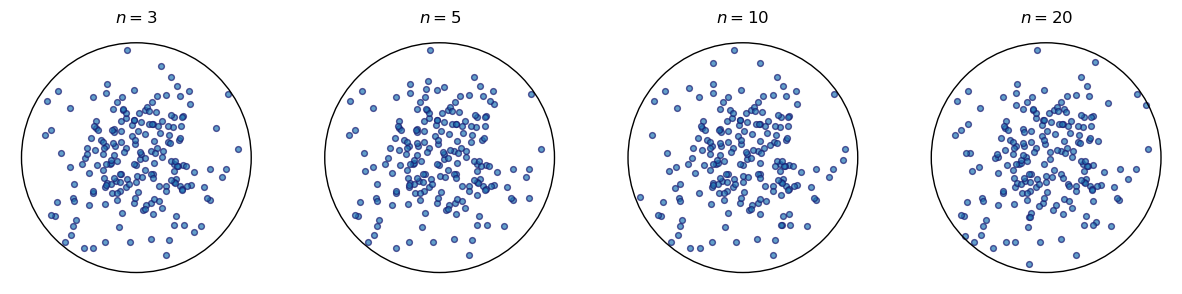

In [84]:
import matplotlib.patches as ps

fig, ax = plt.subplots(nrows=1, ncols=len(nrands), figsize=(15, 15))
plot_kwargs = {
    "s": 17.5,
    "alpha": .7,
    "edgecolor": "midnightblue"
}
circle_kwargs = {
    "xy": (0.0, 0.0),
    "radius": R + 2.5,
    "fill": None
}
for i, nrand in enumerate(nrands):
    positions = np.loadtxt(f"/home/hd/hd_hd/hd_gy283/kmc_project/configs/robustness_acc_nrand={nrand}.txt")
    ax[i].scatter(*positions.T, **plot_kwargs)
    ax[i].set_aspect("equal")
    ax[i].set_title(f"$n={nrand}$")
    ax[i].add_patch(ps.Circle(**circle_kwargs))
    ax[i].spines[["top", "bottom", "right", "left"]].set_visible(False)
    ax[i].set_xticks([])
    ax[i].set_yticks([])
    